# Summary of text descriptives

In [33]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as cm
import numpy as np
import seaborn as sns

In [5]:
# import descriptives
descriptives = pd.read_csv("data/corpus_descriptives.csv")

### Plot descriptives

In [78]:
# plotting functions


def plot_descriptives(df: pd.DataFrame, parameter: str, save_fig: bool=False):
    if f"{parameter}_mean" in df.columns:
        df = df.sort_values(by=f"{parameter}_mean")
    else:
        df = df.sort_values(by=parameter)

    df["x"] = range(len(df.index))
    _ = plt.figure(figsize=(20, 9))

    groups = df.groupby("text_type")
    palette = [cm.to_hex(plt.cm.tab20(i)) for i in range(20)]

    for color, (name, group) in zip(palette, groups):
        x = group["x"]

        if f"{parameter}_mean" in df.columns:
            y = group[f"{parameter}_mean"]
            y_std = group[f"{parameter}_std"]
            plt.errorbar(x, y, yerr=y_std, fmt="o", label=name, markersize=10, color=color)
        else:
            y = group[parameter]
            plt.errorbar(x, y, fmt="o", label=name, markersize=10, color=color)
        plt.ylabel(parameter)

    text_names = df["file_name"]
    plt.xticks(df["x"], text_names, rotation=90)
    plt.grid(color="grey")
    plt.legend()
    if save_fig:
        plt.savefig(f"figs/{parameter}.png", bbox_inches="tight")
    plt.show()


def plot_descriptives_group_mean(df: pd.DataFrame, parameter: str, save_fig: bool=False):
    _ = plt.figure(figsize=(20, 9))

    groups = df.groupby("text_type")

    x, y, y_std = [], [], []
    for name, group in groups:
        x.append(name)
        y.append(np.mean(group[parameter]))
        y_std.append(np.std(group[parameter]))
    
    plt.errorbar(x, y, yerr=y_std, fmt="o", markersize=10)
    plt.xticks(rotation=90)
    plt.ylabel(parameter)

    if save_fig:
        plt.savefig(f"figs/{parameter}_group_mean.png", bbox_inches="tight")
    plt.show()


def plot_relevant_parameters(
        df: pd.DataFrame,
        x_parameter: str, 
        y_parameter: str, 
        color_parameter: str=None,
        title: str=None,
        save_fig: bool=False):
    
    sns.relplot(
        data=df, 
        x=x_parameter, 
        y=y_parameter, 
        hue=color_parameter
    )

    for i, txt in enumerate(df["Number"]):
        plt.annotate(txt, (df[x_parameter][i], df[y_parameter][i]))
    
    if title:
        plt.title(title)

    if save_fig:
        plt.savefig(f"figs/{x_parameter}_and_{y_parameter}.png", bbox_inches="tight")
    plt.show()

**Parameter values for each text**

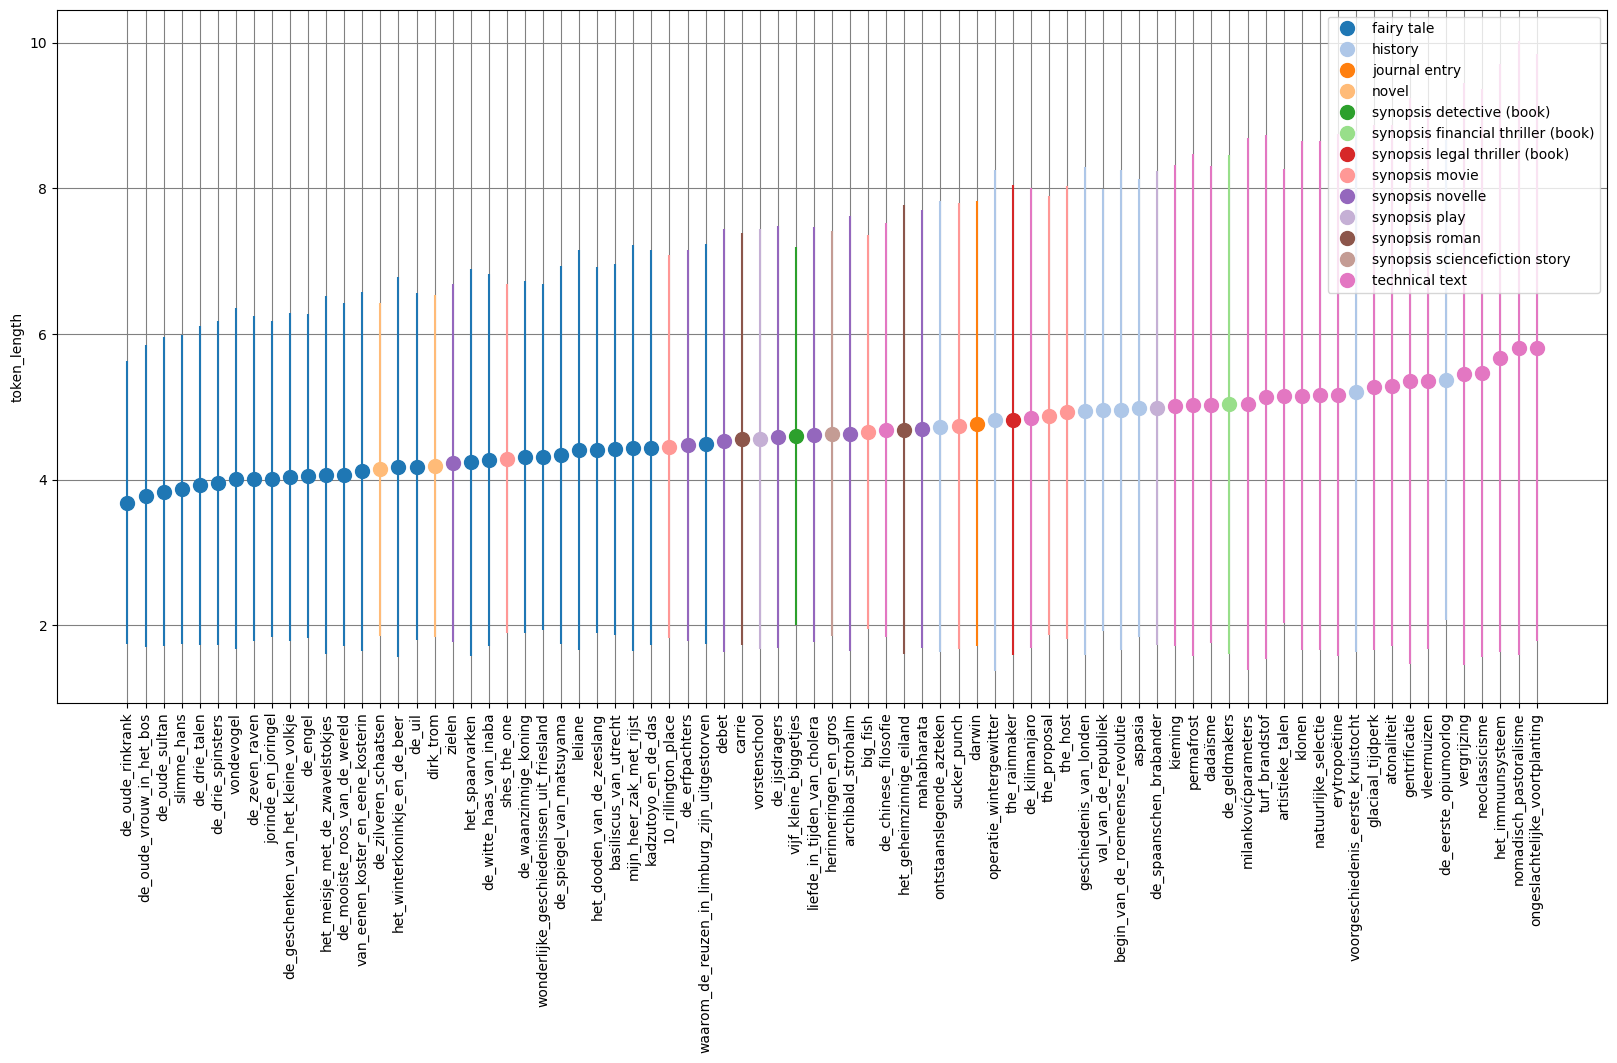

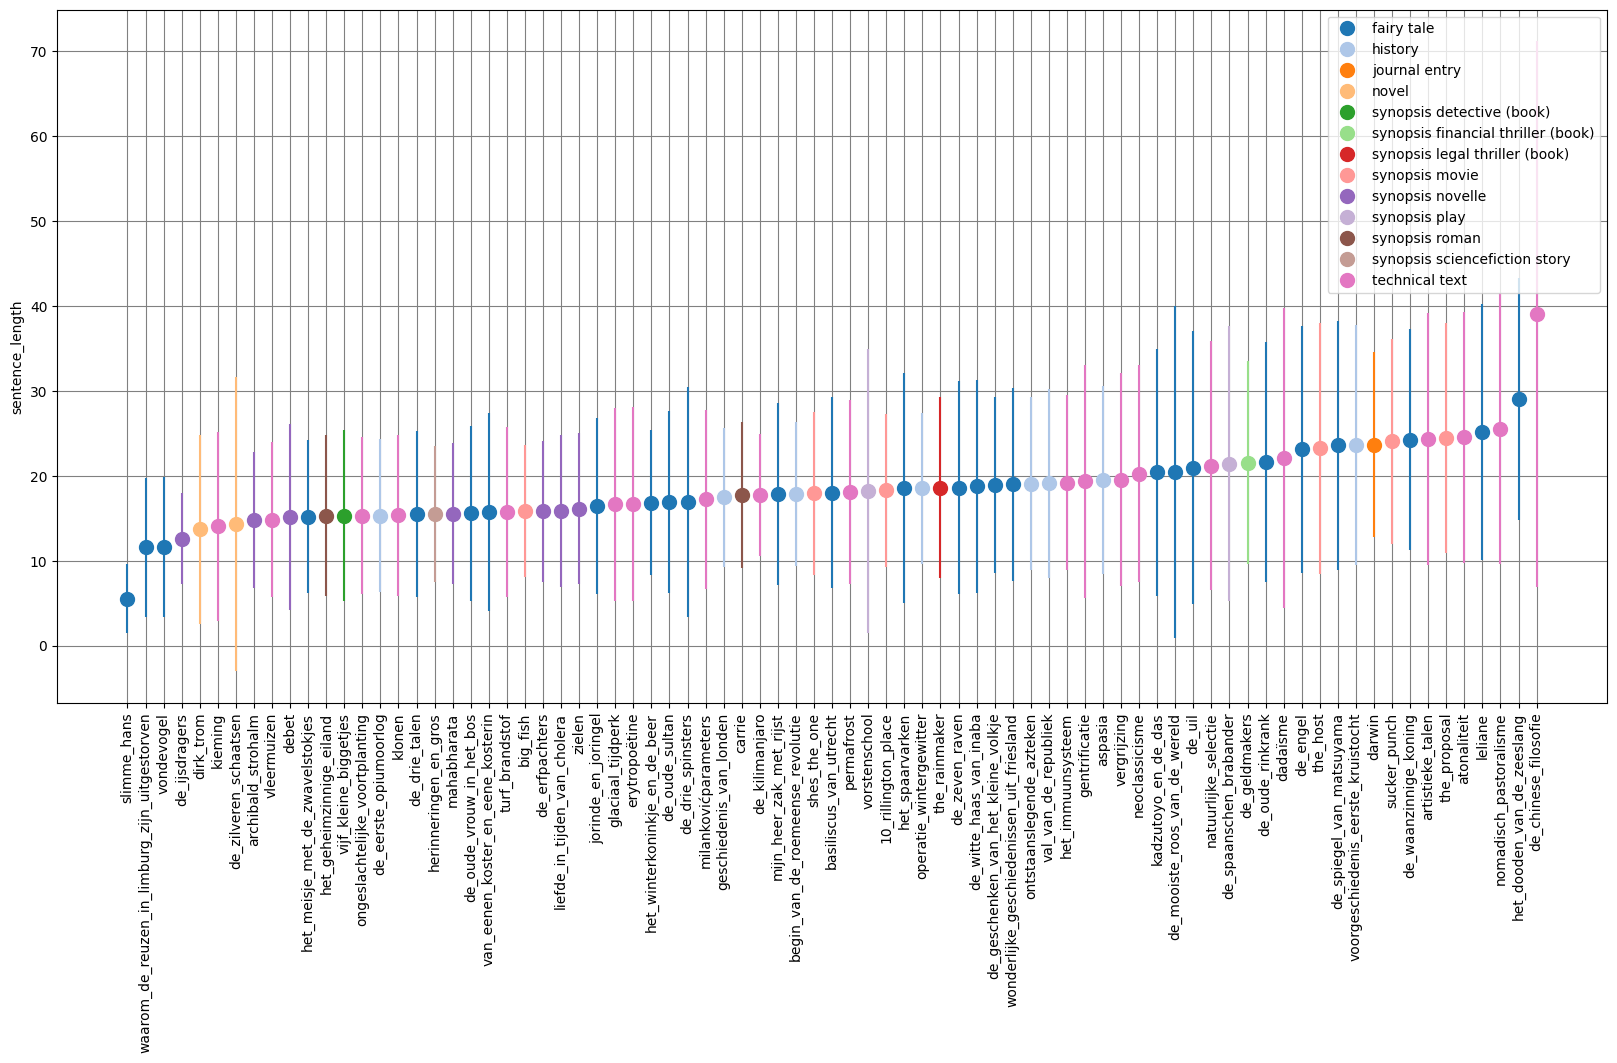

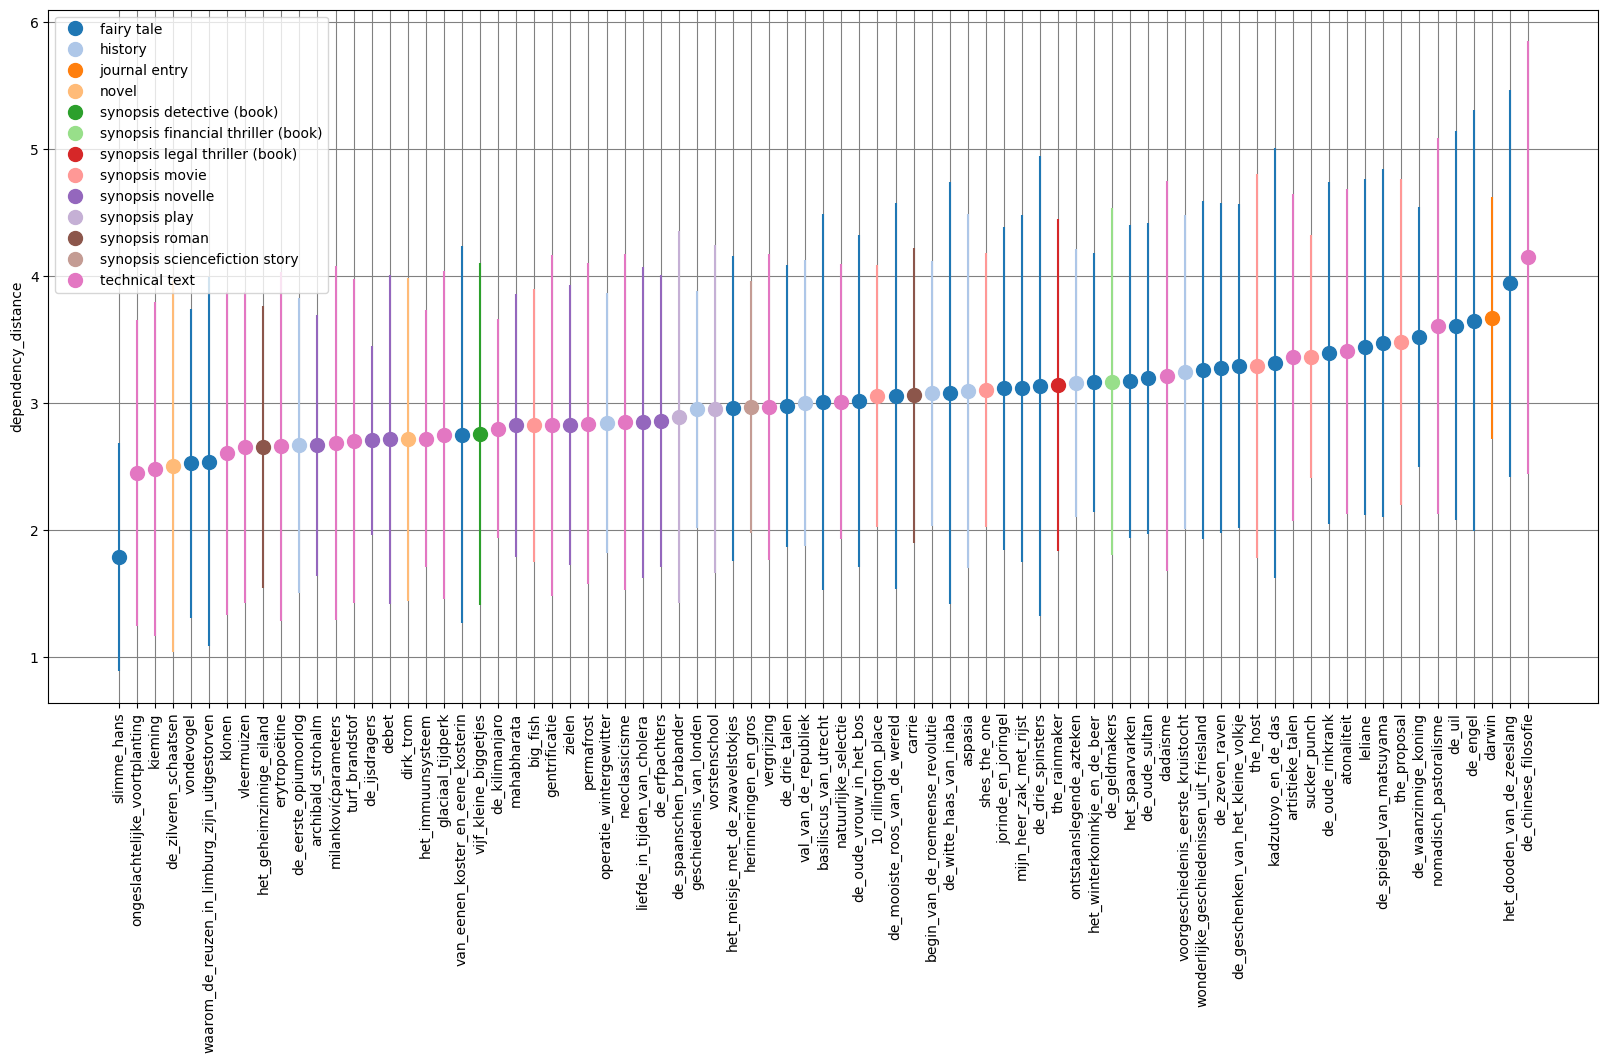

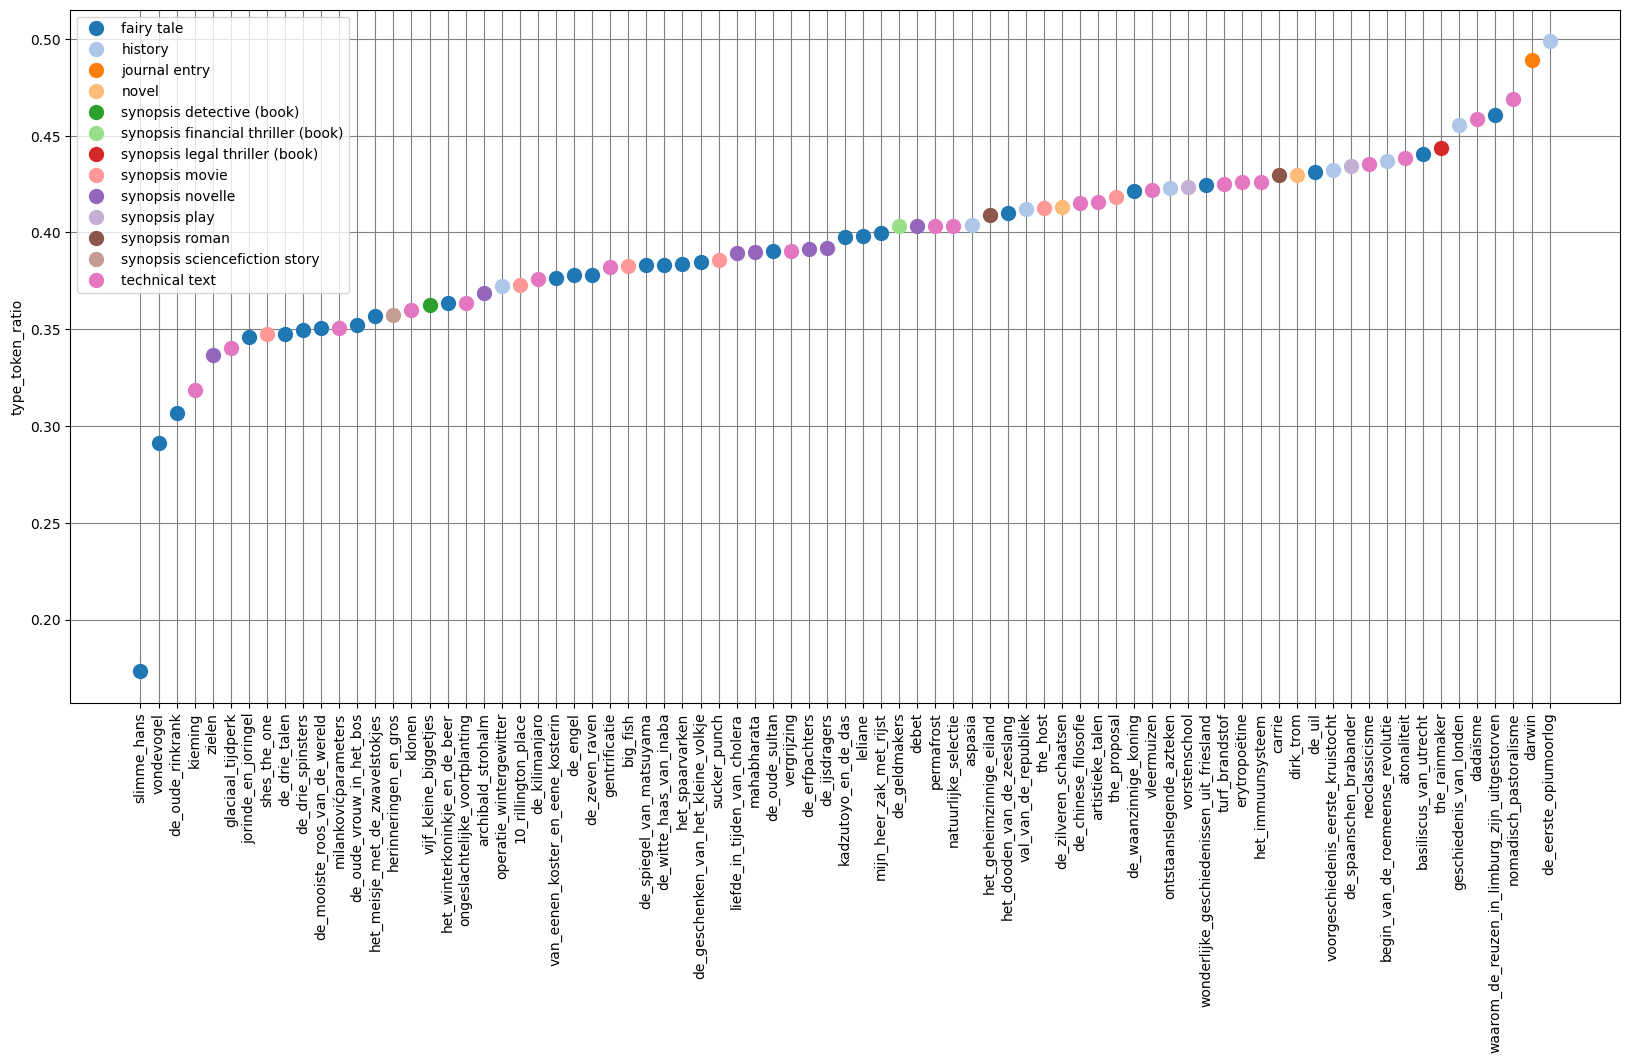

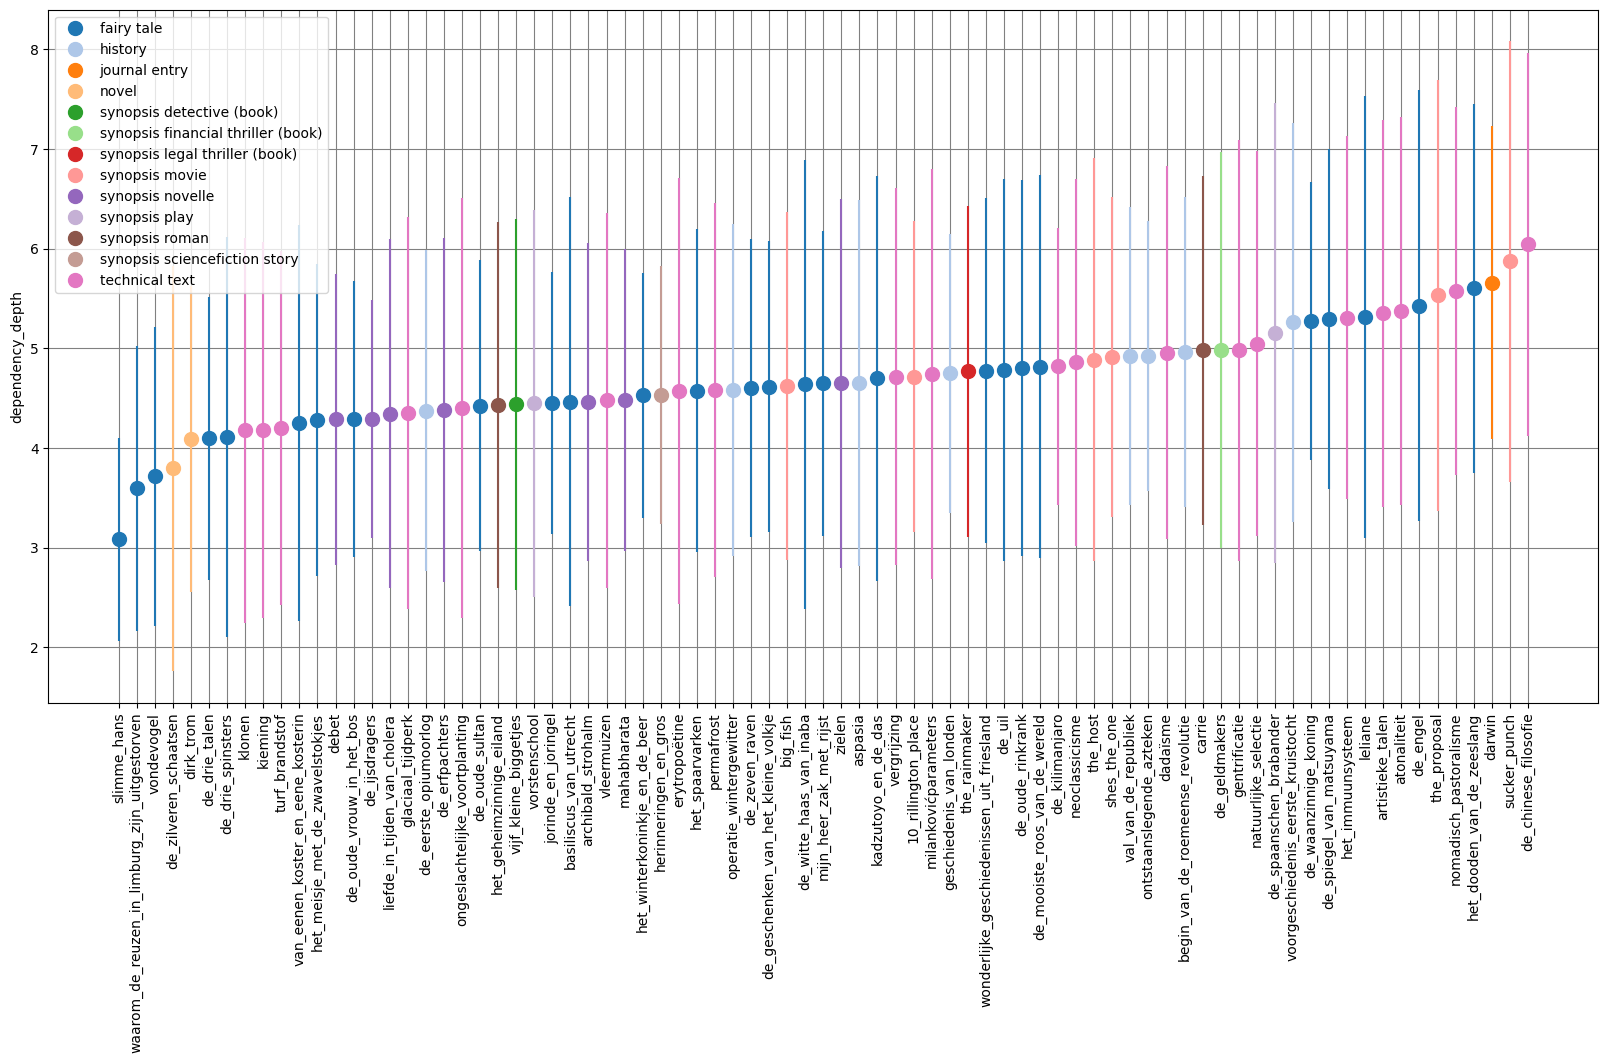

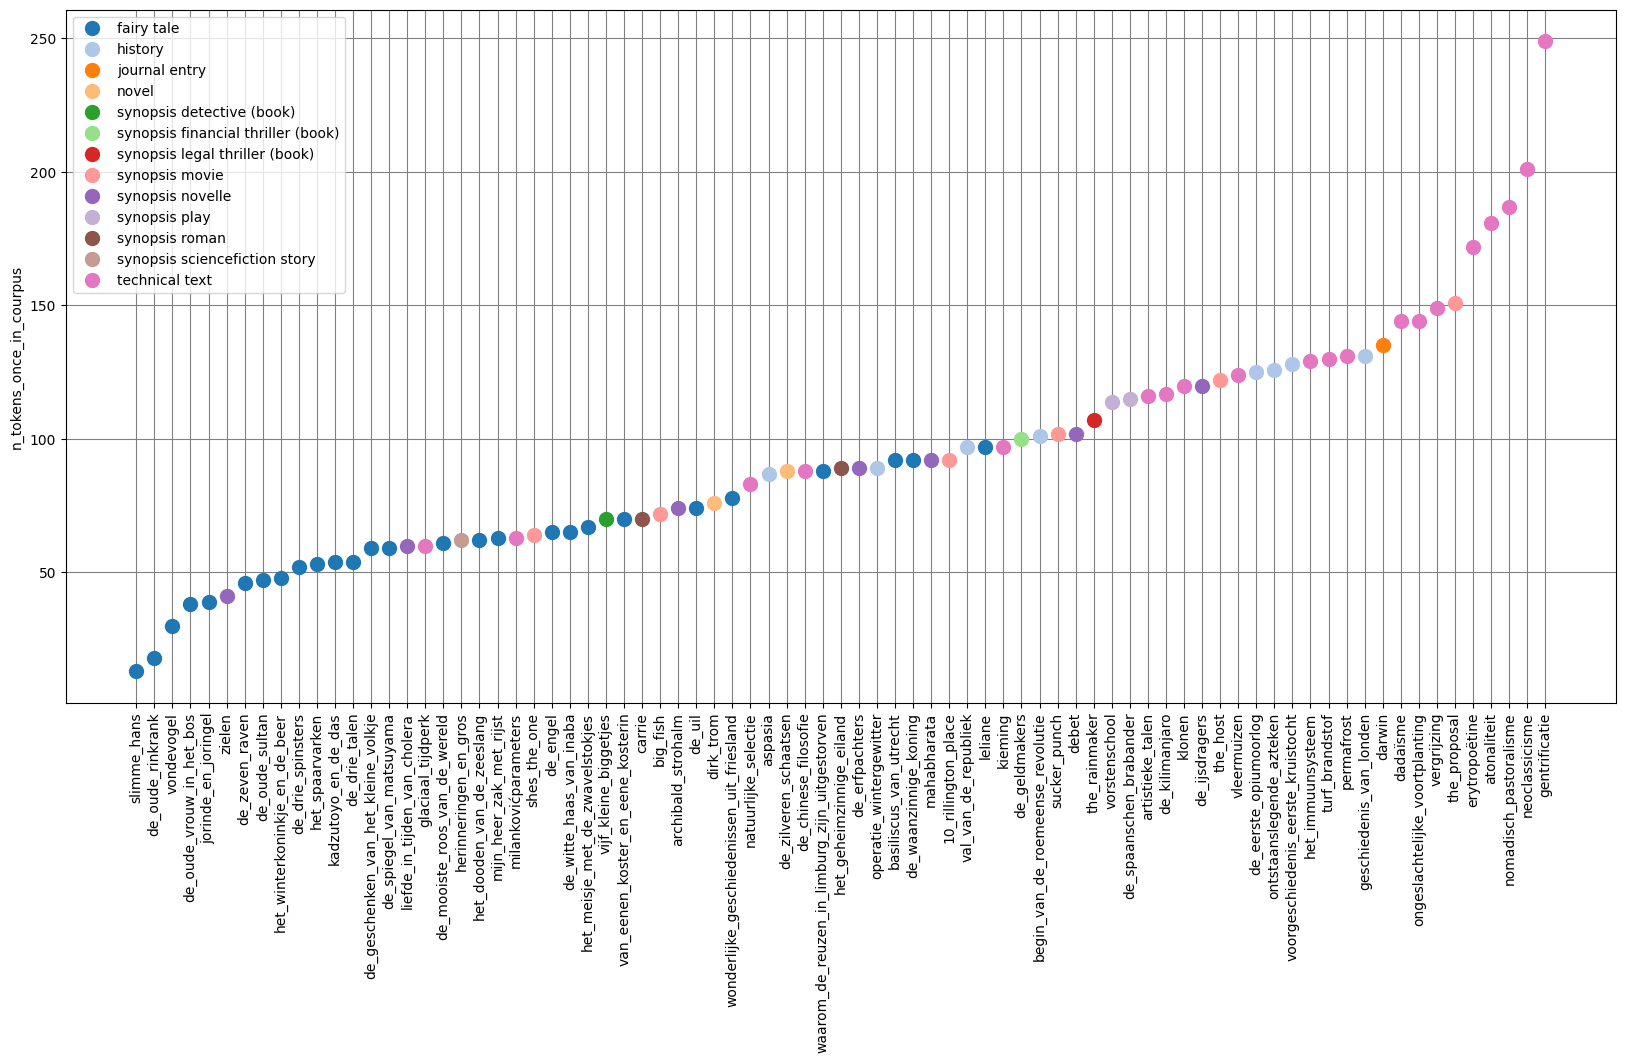

In [27]:
plot_parameters = [
        "token_length",
        "sentence_length",
        "dependency_distance",
        "type_token_ratio",
        "dependency_depth",
        "n_tokens_once_in_courpus",
    ]

for parameter in plot_parameters:
    plot_descriptives(descriptives, parameter, save_fig=True)

**Descriptives summarized for different types of texts**

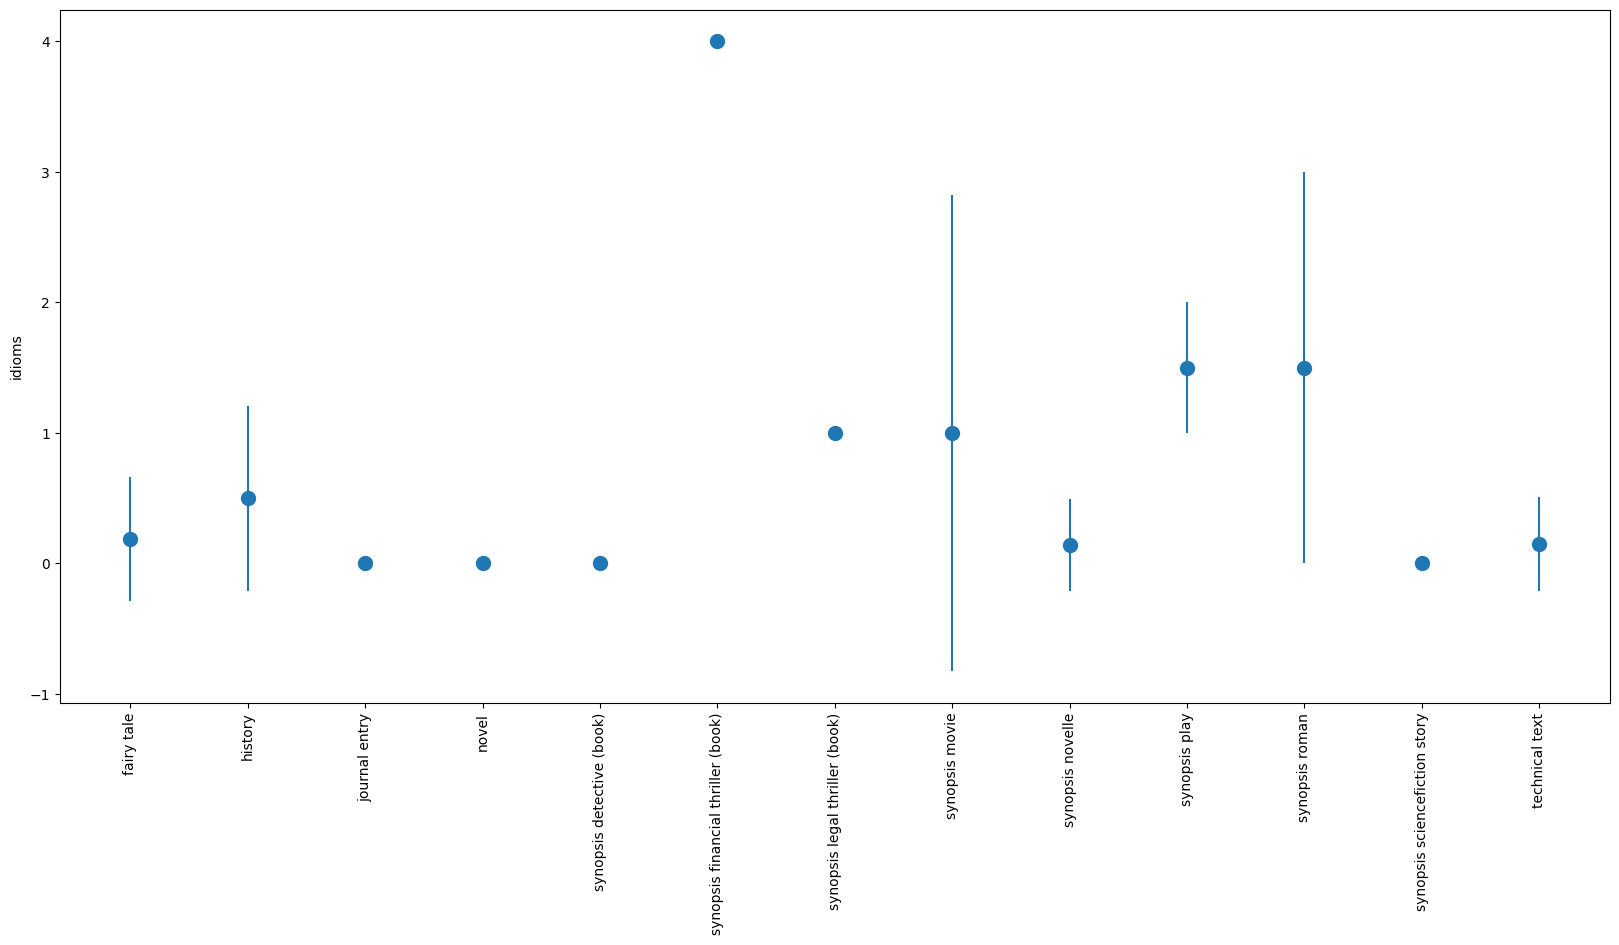

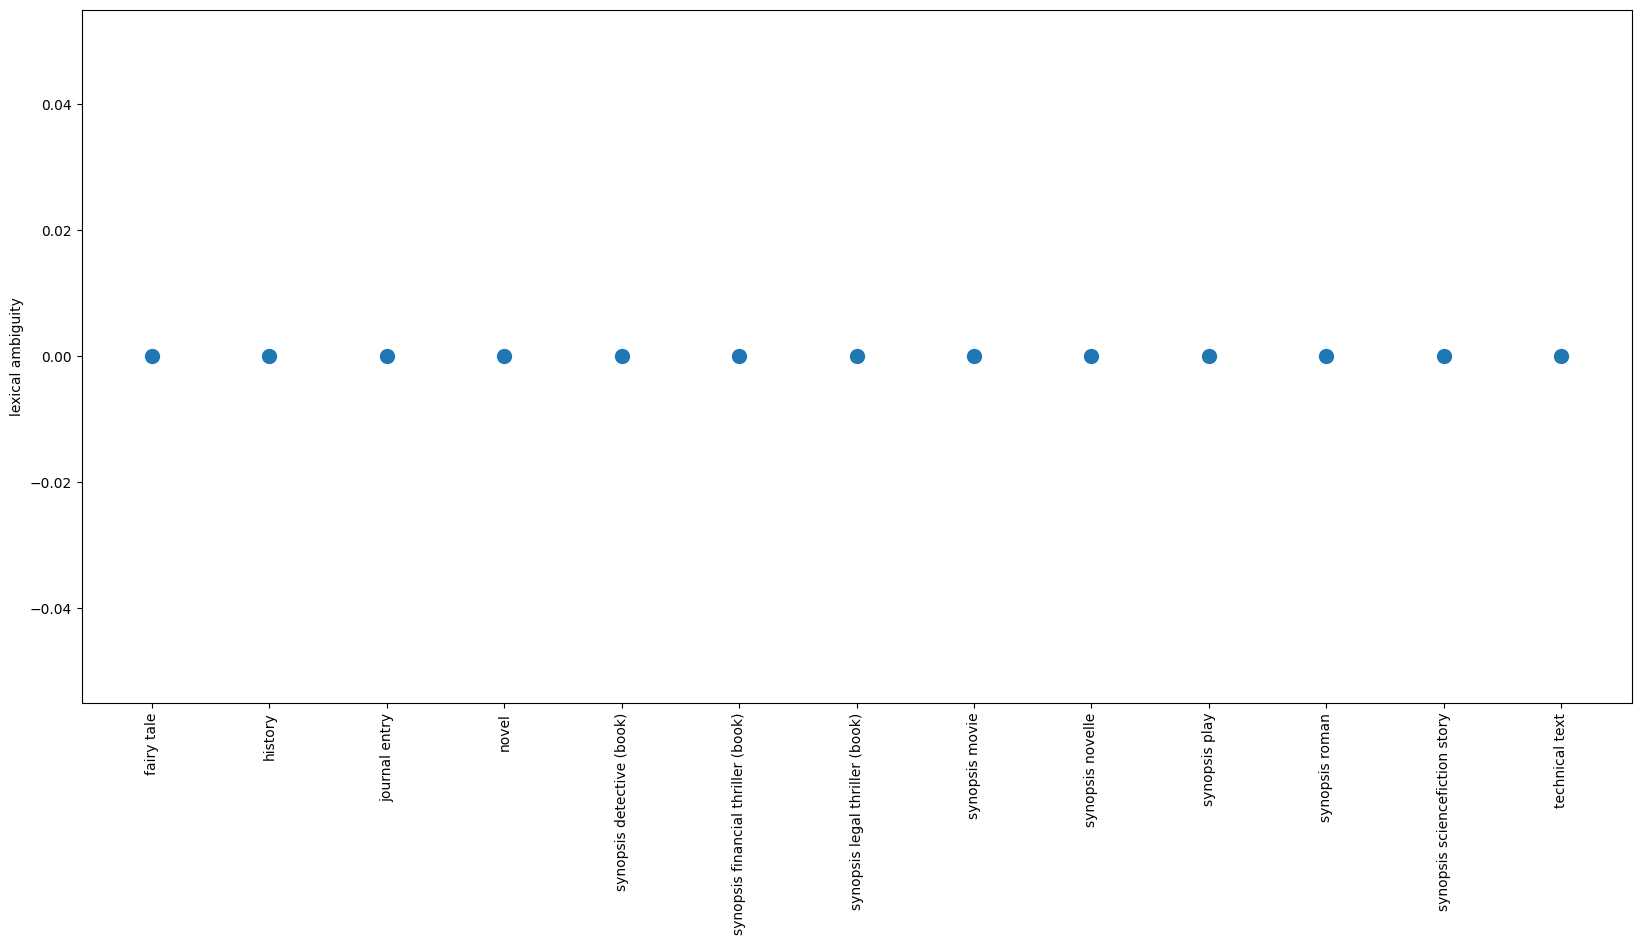

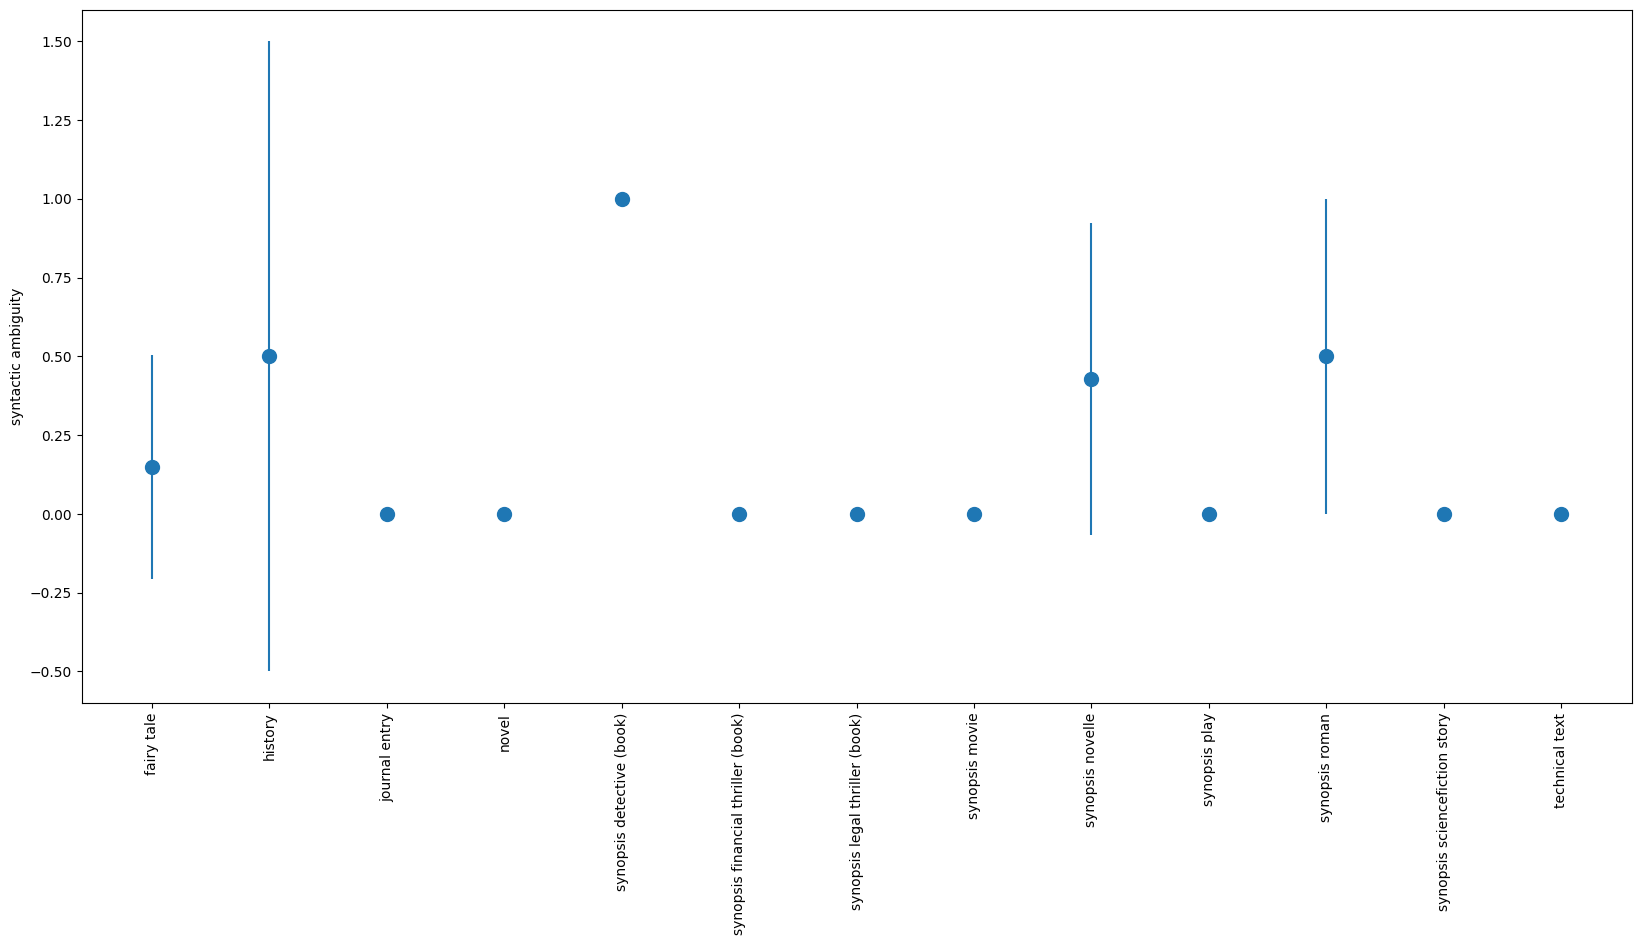

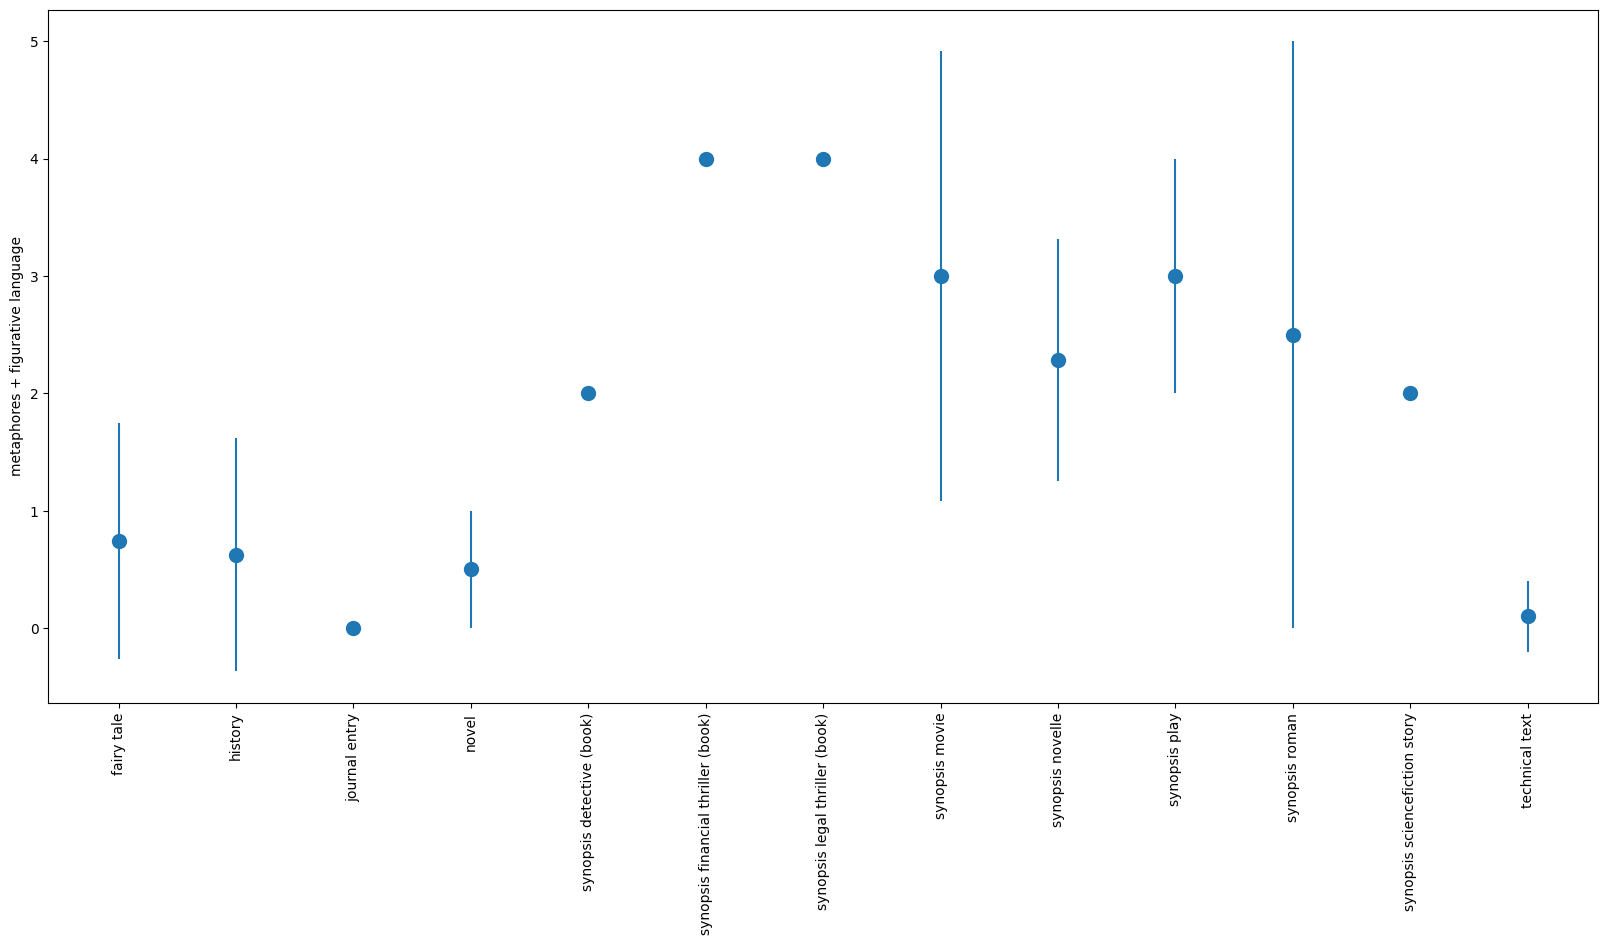

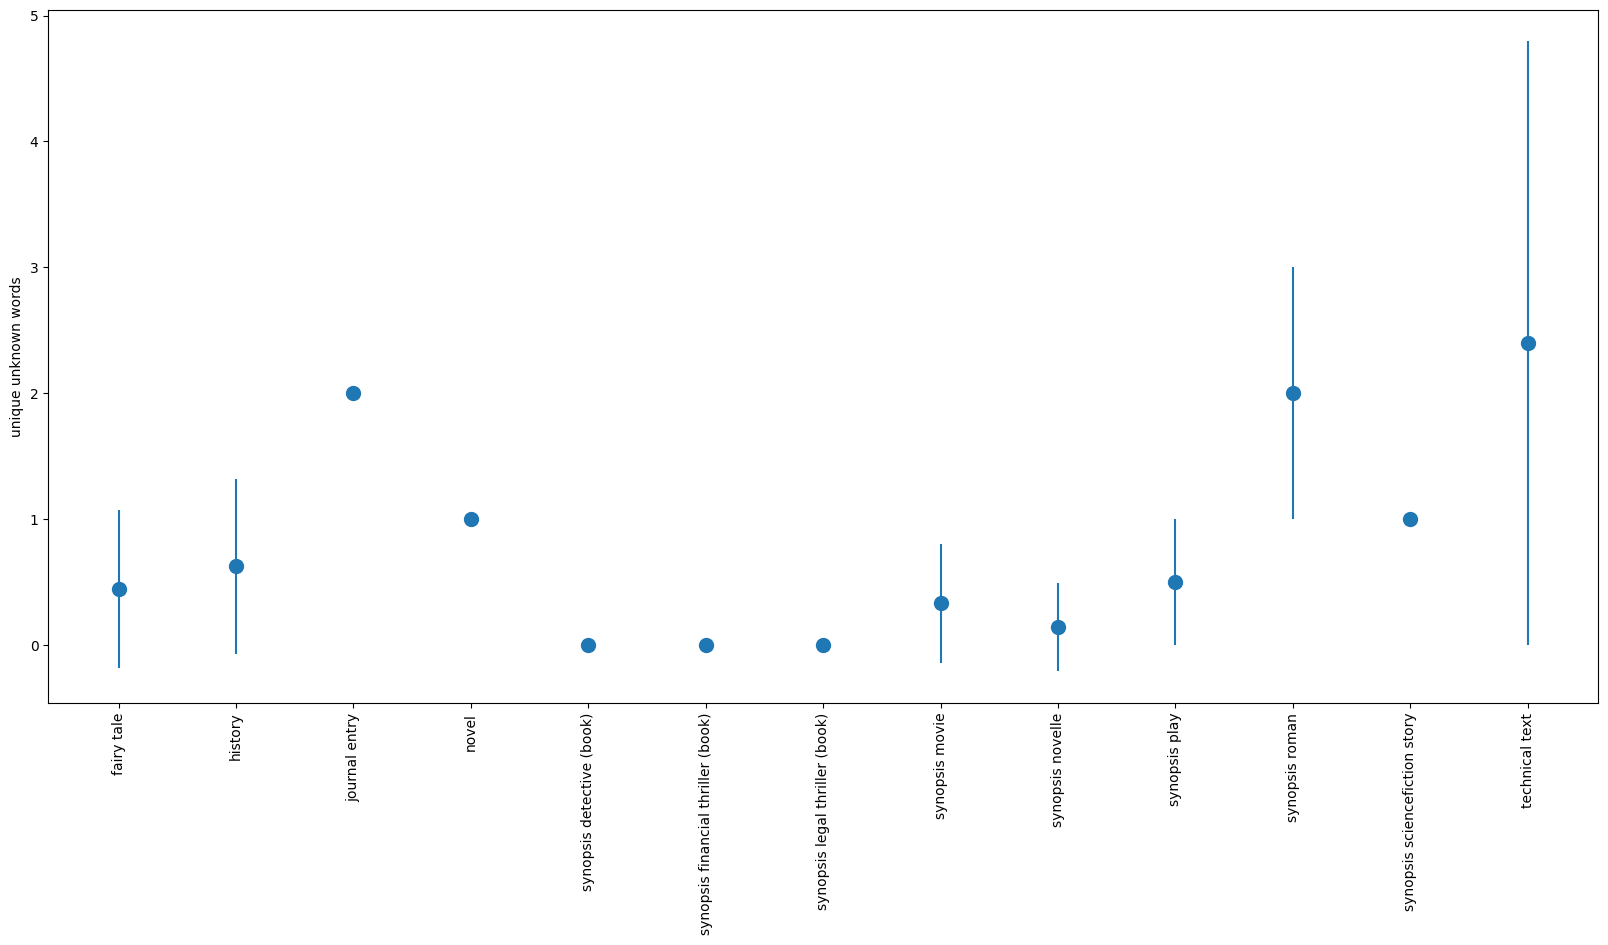

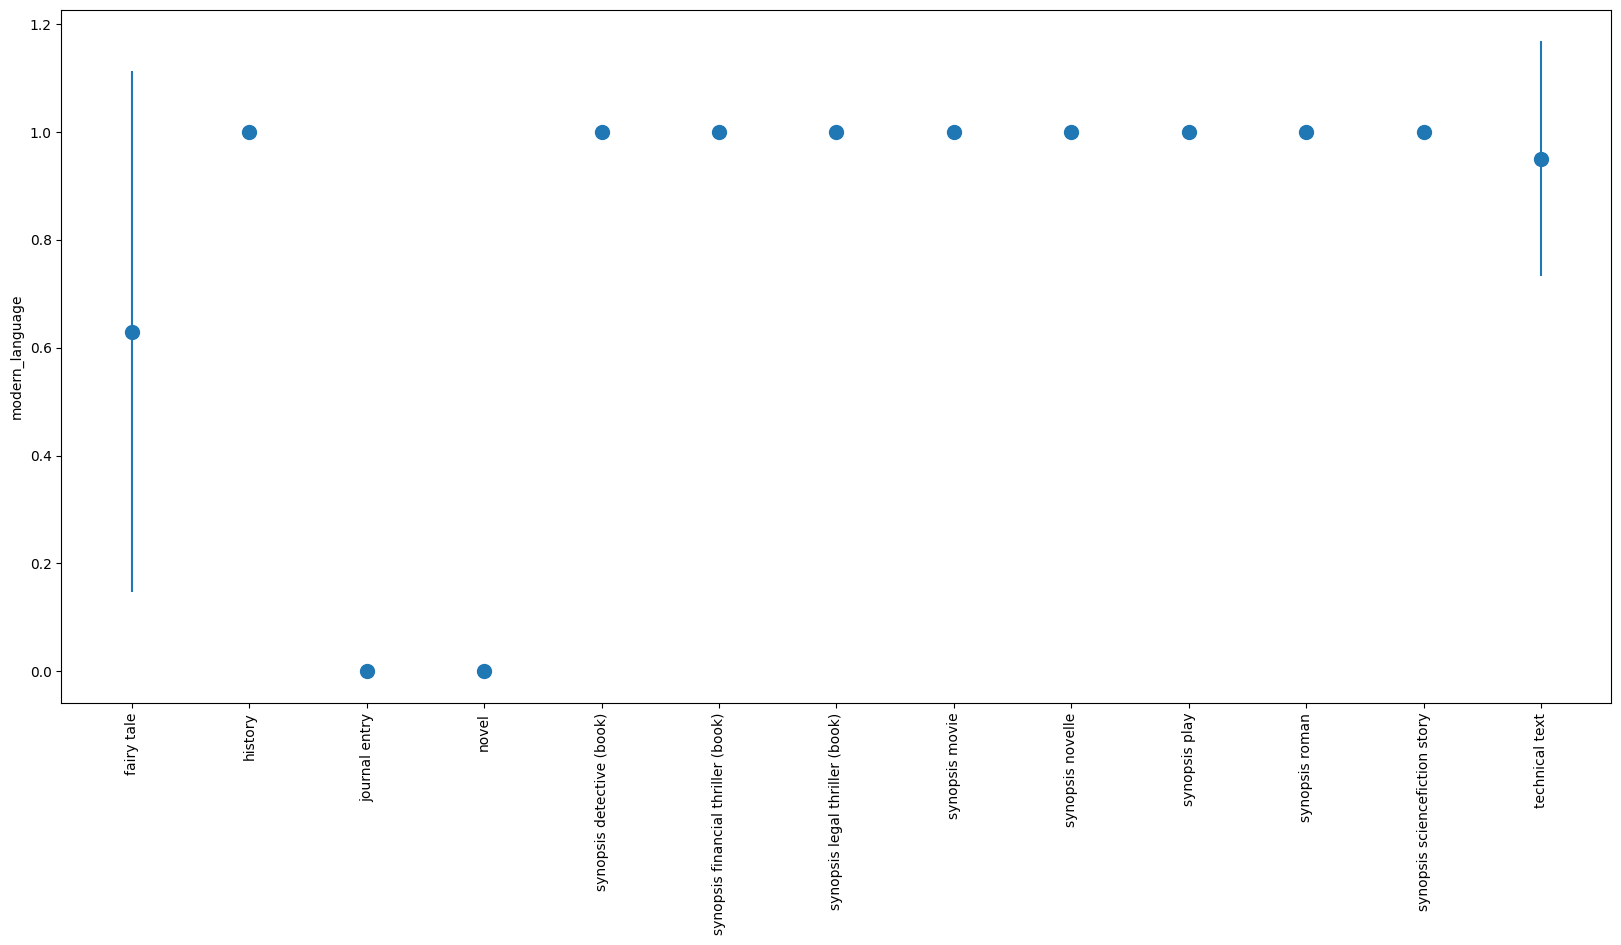

In [78]:
# text parameters contructed by RAs
descriptives["modern_language"] = [
    1 if language=="Modern" or language=="Modern " else 0 for language in descriptives["type of language"]
    ]

plot_parameters = [
        "idioms",
        "lexical ambiguity",
        "syntactic ambiguity",
        "metaphores + figurative language",
        "unique unknown words",
        "modern_language"
    ]

for parameter in plot_parameters:
    plot_descriptives_group_mean(descriptives, parameter, save_fig=True)

**Select texts**

In [20]:
# exclude texts based on notes
badly_written = [
    "De ijsdragers",
    "De geldmakers",
    "Zielen"
]

bad_translations = [
    "Big Fish",
    "Vijf kleine biggetjes",
    "She's the one",
    "The Proposal",
    "The Host",
    "sucker_punch",
    "Liefde in tijden van cholera",
    "De erfpachters",
    "The Rainmaker"
]

exclude_texts = badly_written + bad_translations

filtered_descriptives = descriptives[~descriptives["Filename"].isin(exclude_texts)]

In [23]:
filtered_descriptives["text_type"] = [
    "synopsis" if "synopsis" in text_type else text_type for text_type in filtered_descriptives["text_type"]
    ]

C:\Users\ostergaa\AppData\Local\Temp\ipykernel_10252\543864304.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_descriptives["text_type"] = [


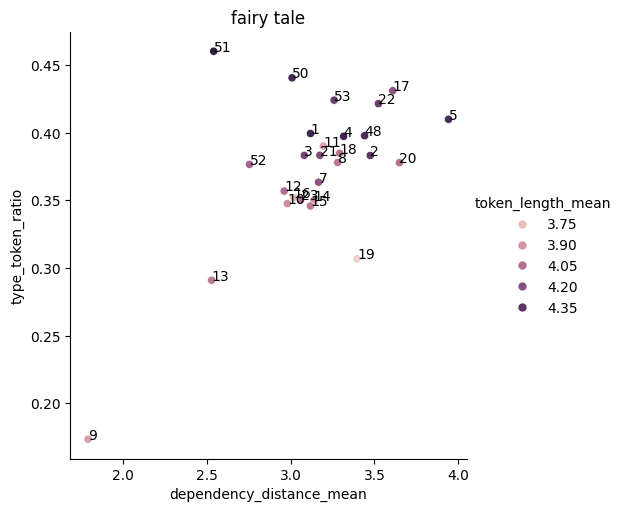

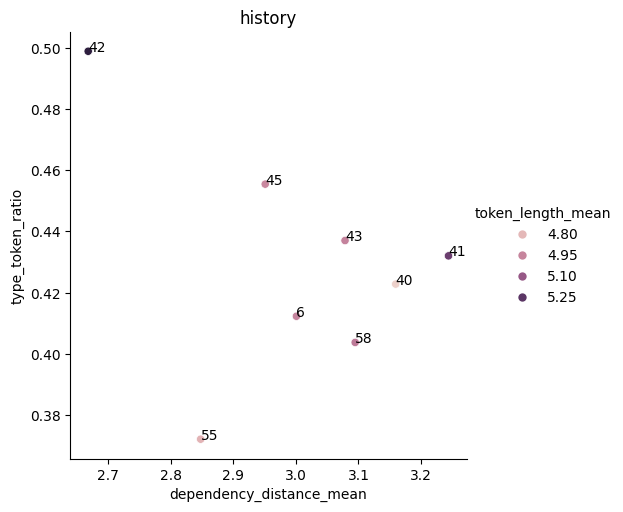

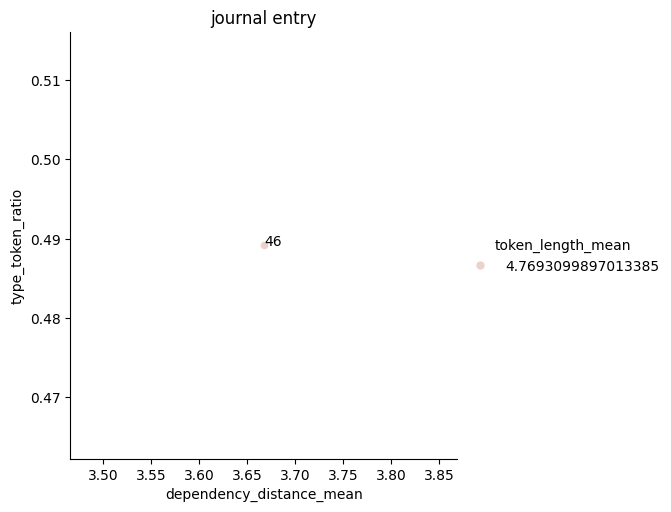

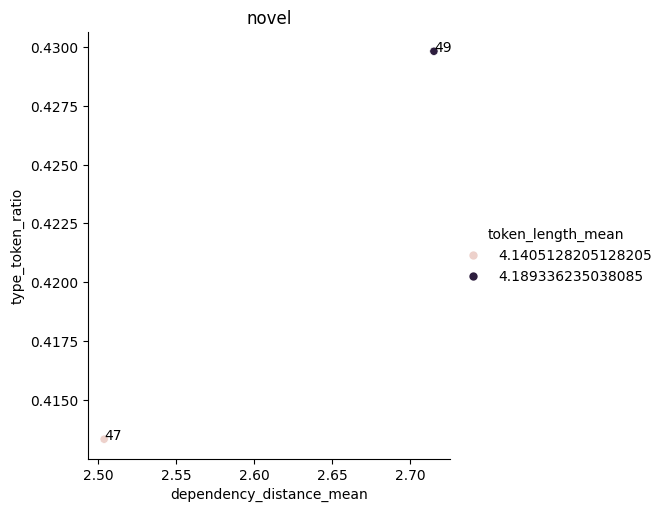

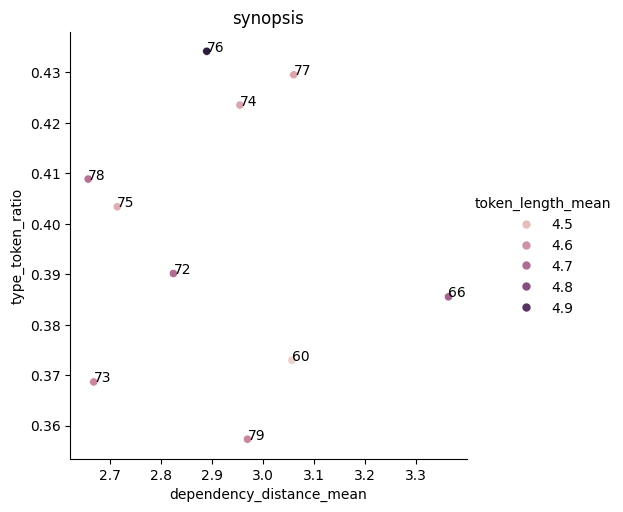

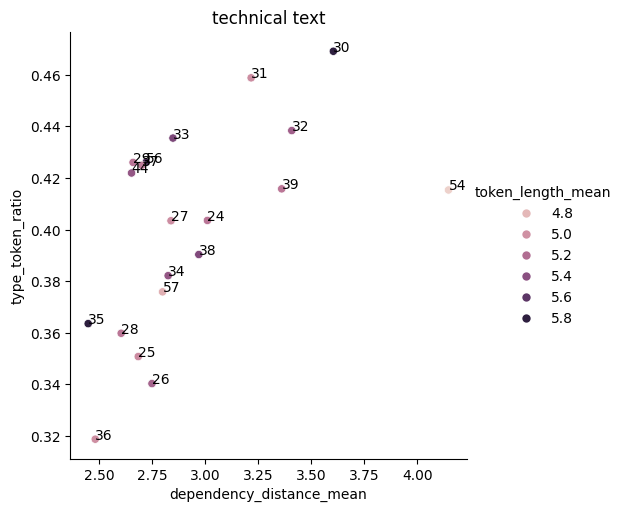

In [89]:
groups = filtered_descriptives.groupby("text_type")

for name, group in groups:
    group = group.reset_index()
    plot_relevant_parameters(
        group, 
        "dependency_distance_mean",
        "type_token_ratio",
        color_parameter="token_length_mean",
        title=name)

In [90]:
chosen_fairytales = [
    # low complexity
    9,  # low values generally -> maybe too low?
    13, # same as 9, just closer to rest of fairy tales

    # medium
    51, # high type_token_ratio and token_length, same (low) dependency_distance as 13
    50, # similar as 51, but with higher dependency distance
    19, # low type_token_ratio and token_length, medium/high dependency distance

    # high complexity
    5, 17, 22
]

chosen_history = [
    42, # (very) low depencency distance, high type_token ratio
    55, # low type_token ratio, dependency distance
    41, # high dependency distance, medium type_token ratio
]

# so few all is chosen
chosen_journal = [46]
chosen_novel = [47, 49]

chosen_synopsis = [
    73, # low values
    78, # high type_token ratio, low dependency distance
    76, # high type_token ratio + token_length, low dependency distance
    66  # high depencency distance low type_token ratio
]

chosen_technical = [
    # low values
    36, 26,
    35, # + high token_length

    # high values
    30, 32,
    31, # + low token_length
    54, # + low token_length and lowish type_token ratio
]

chosen_texts_number = chosen_fairytales + chosen_history + chosen_journal + chosen_novel + chosen_synopsis + chosen_technical

In [103]:
cols_to_check = [
    "text_type",
    "file_name",
    "idioms",
    "syntactic ambiguity",
    "metaphores + figurative language",
    "unique unknown words",
    "type of language"
]

descriptives[descriptives["Number"].isin(chosen_texts_number)][cols_to_check].sort_values(by="text_type")

,text_type,file_name,idioms,syntactic ambiguity,metaphores + figurative language,unique unknown words,type of language
76,fairy tale,waarom_de_reuzen_in_limburg_zijn_uitgestorven,1,0,0,1,Old spelling
73,fairy tale,vondevogel,0,0,0,0,Modern
5,fairy tale,basiliscus_van_utrecht,0,0,2,2,Old spelling
62,fairy tale,slimme_hans,0,0,0,0,Modern
23,fairy tale,de_oude_rinkrank,0,0,0,0,Modern
39,fairy tale,het_dooden_van_de_zeeslang,0,0,0,0,Old spelling
28,fairy tale,de_uil,0,0,3,0,Modern
29,fairy tale,de_waanzinnige_koning,1,0,4,0,Modern
59,history,operatie_wintergewitter,1,0,0,0,Modern
15,history,de_eerste_opiumoorlog,0,0,1,2,Modern


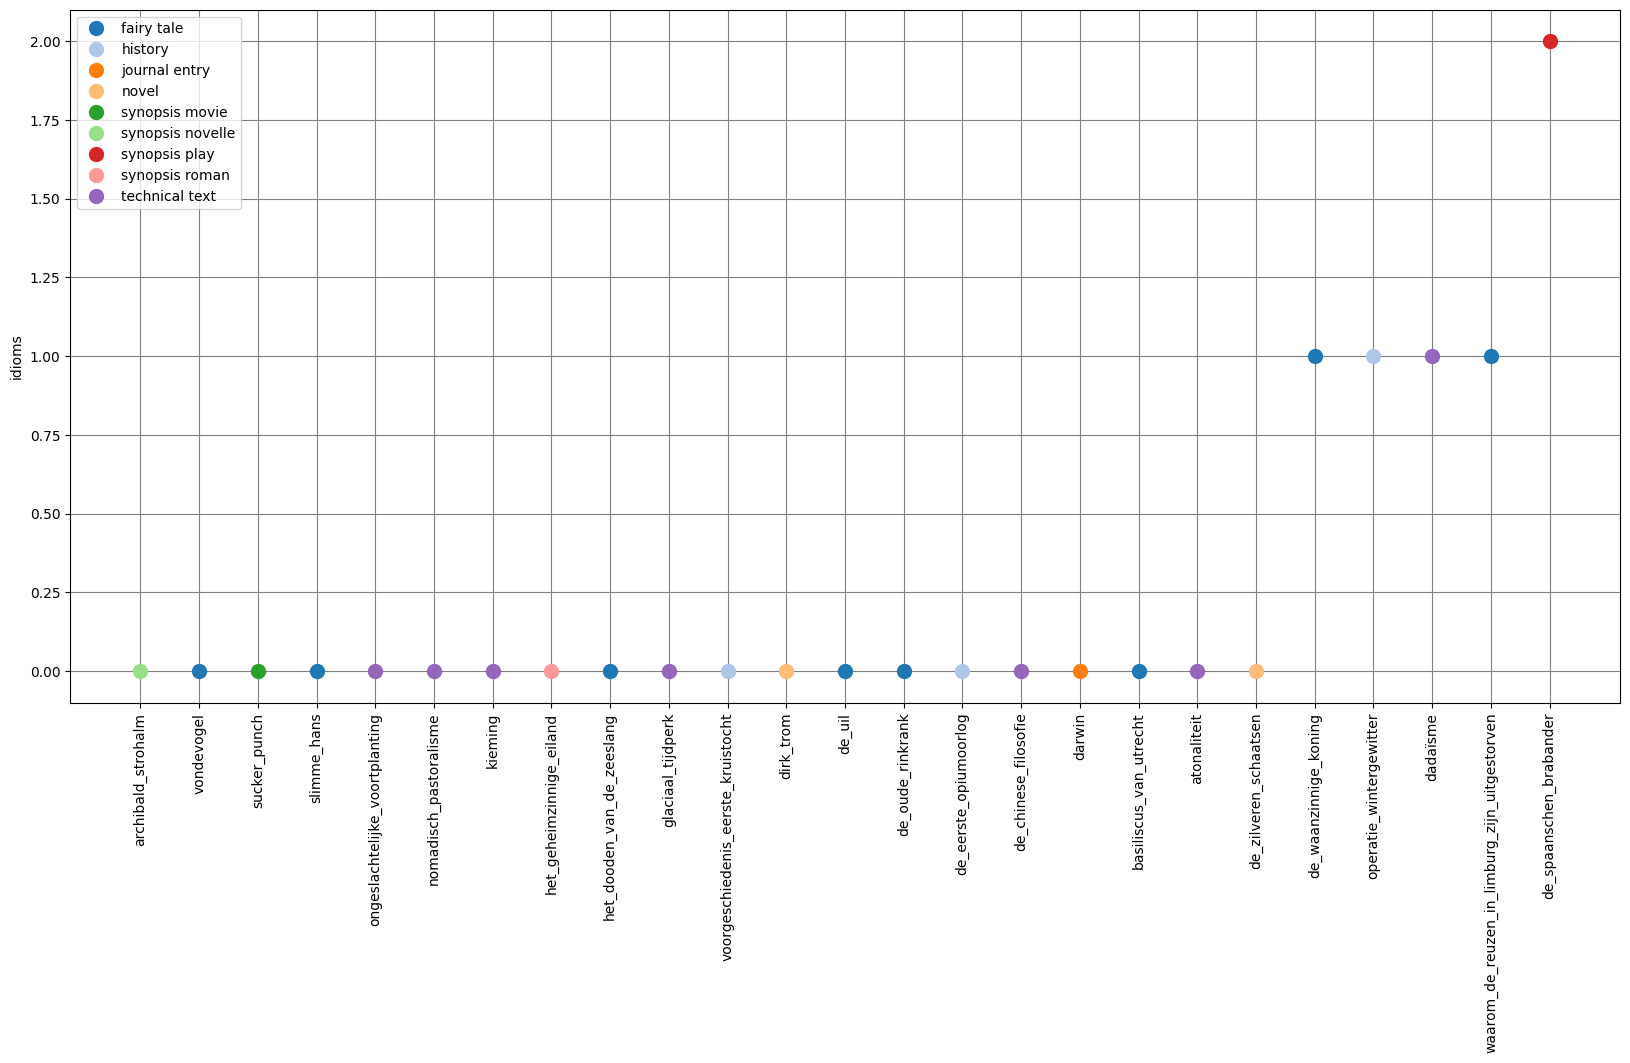

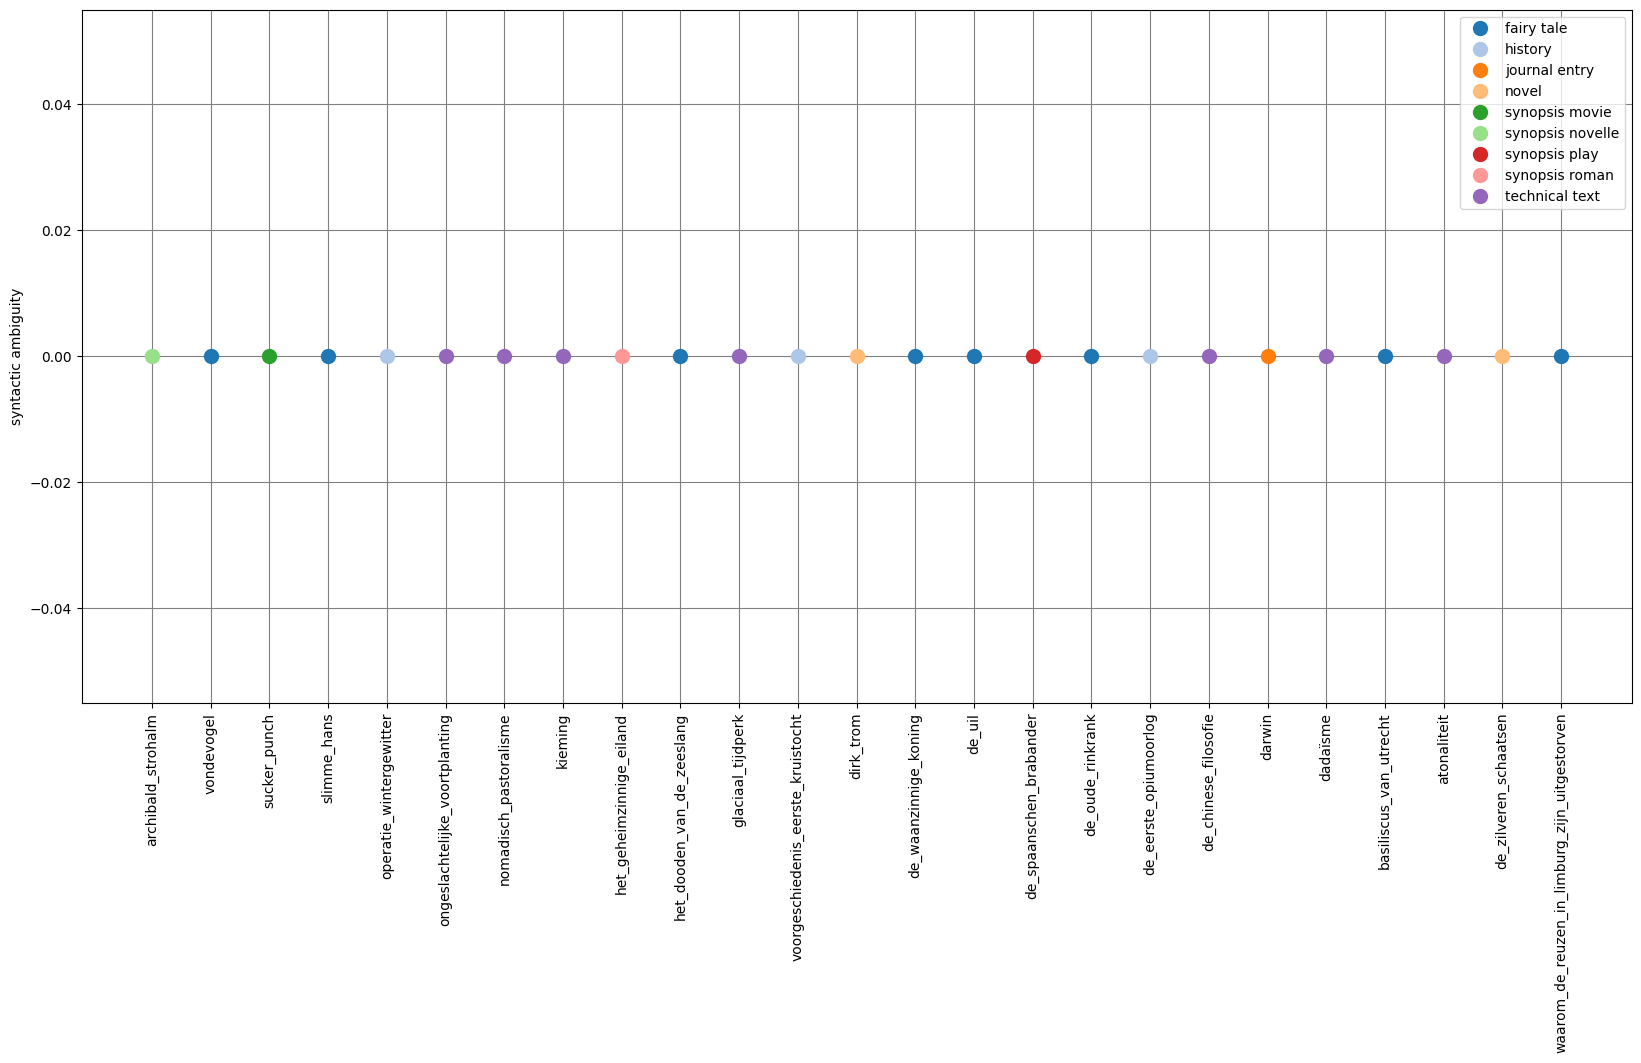

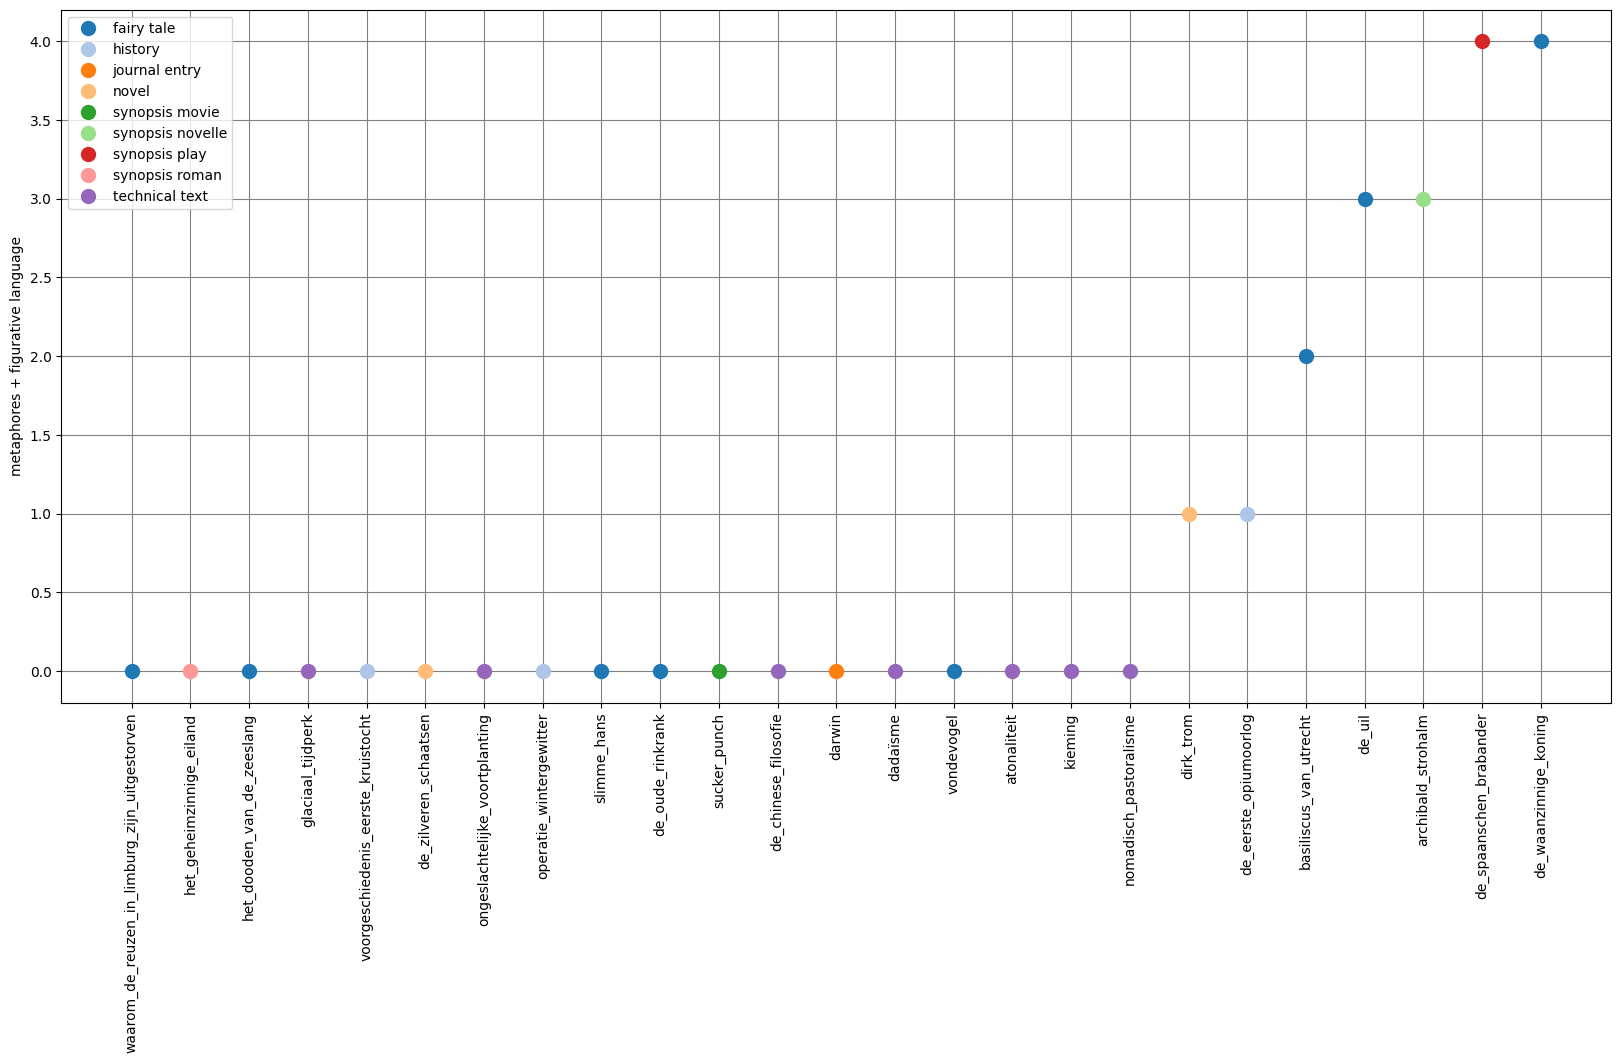

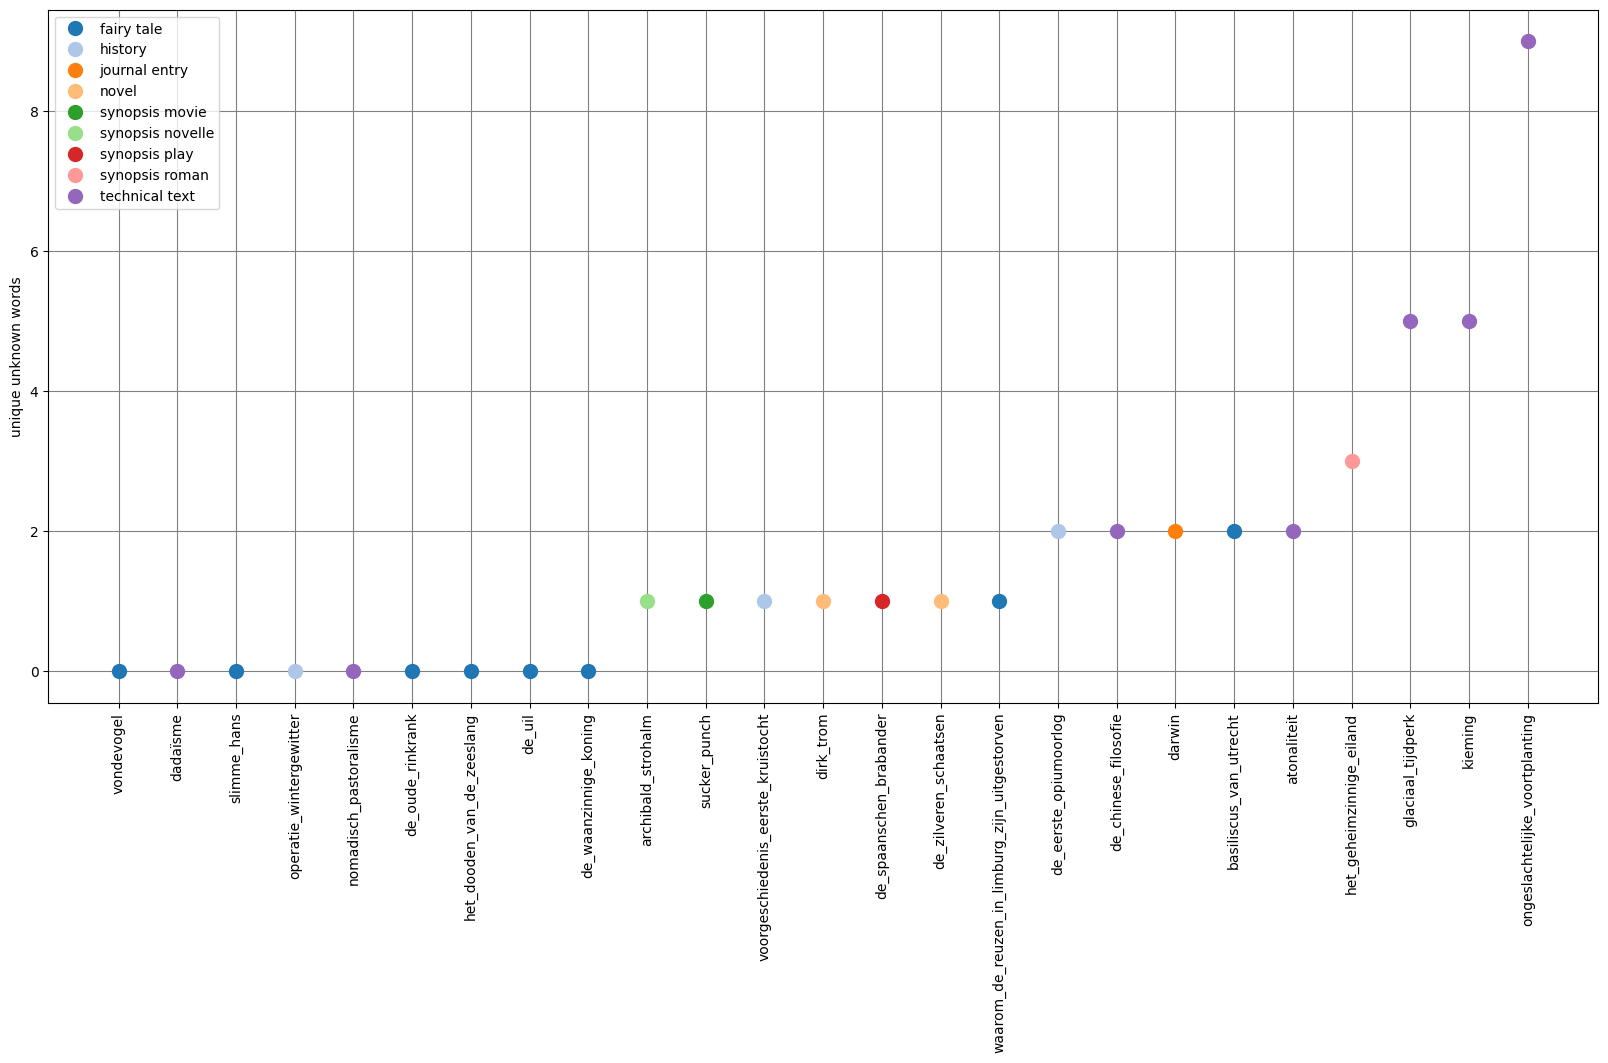

In [95]:
plot_parameters = [
        "idioms",
        "syntactic ambiguity",
        "metaphores + figurative language",
        "unique unknown words"
    ]

for parameter in plot_parameters:
    plot_descriptives(
        descriptives[descriptives["Number"].isin(chosen_texts_number)], 
        parameter, save_fig=False)